> ✋ **New to this architecture?** Walk through [`00_climb_to_compound.ipynb`](./00_climb_to_compound.ipynb) first — minimal multi-plane intro (runs in <60s with `PYAUTOFIT_TEST_MODE=1`).

---


# Compound Lens — SLaM Variants (dual-track)

## Learning to Autolens / Examples / compound_lens

---

**Problem.** Same data and geometry as `01_compound_direct_fit.ipynb`: lens at z=0.5, lens at z=0.8, source at z=1.7.

**Method.** Two SLaM-style approaches, side by side:

- **Track A — single-effective-deflector simplification.** Ignore the second lens, fit one Isothermal + external shear, let shear absorb the asymmetry. Uses the stock `slam_v2026` pipeline unchanged.
- **Track B — staged two-deflector chain.** Three searches written inline: (1) fit only the z=0.5 lens + source; (2) freeze the primary, add the z=0.8 lens; (3) joint refinement. This is what the `slam_v2026` shim would look like if it supported multiple lenses — PyAutoLens already has the machinery via `al.Tracer`, so the work is just chaining priors across stages.

**Why both?** Track A is the pedagogical first-pass: it teaches you *when a simplification is valid*. Track B is what you publish when the simplification breaks. The comparison at the end is the learning objective.

**Prerequisites.** `01_compound_direct_fit.ipynb`, Mod 04 (SLaM), Mod 11 (physical-bar audit). The multi-plane PyAutoLens API is documented in `autolens_workspace_latest/scripts/guides/advanced/multi_plane.py` — recommended reading before this notebook.

> **Update (2026-04-24) — read first.** The direct-fit baseline used throughout this notebook is `v3` (Isothermal, no shear) — the canonical 01 fit when this comparison was first shipped. Notebook 01 has since been upgraded through **v4** (Iso+shear, log_Z=+30,856), **EPL** (PowerLaw+shear, log_Z=+31,000, max|res|=3.82σ), and **PIX** (pixelised source, log_Z=+31,107). For the current state-of-the-art comparison, see [`03_compound_advanced_models.ipynb`](03_compound_advanced_models.ipynb). The three-way (direct/A/B) story below is preserved unchanged: it is still the cleanest pedagogical demonstration of the *forced-compound suboptimum* (Pattern E in `LEARNING_LOG.md`). A refreshed five-way table appears below the original comparison.

---


In [1]:
import os
if os.environ.get("PYAUTOFIT_TEST_MODE"):
    raise RuntimeError(
        f"PYAUTOFIT_TEST_MODE={os.environ['PYAUTOFIT_TEST_MODE']!r} is set."
    )

import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, IFrame, Markdown, display

import autofit as af
import autolens as al
import autolens.plot as aplt

# slam_v2026 shim for Track A
sys.path.insert(0, str(Path("../..").resolve()))
from slam_v2026 import source_lp, source_pix, light_lp, mass_total

%matplotlib inline
print(f"PyAutoLens version: {al.__version__}")

PyAutoLens version: 2026.4.13.6


In [2]:
RESULTS_ROOT = Path("results")

def show_result(stage_name):
    stage_dir = RESULTS_ROOT / stage_name
    if not stage_dir.exists():
        print(f"(no results for stage {stage_name!r} yet)")
        return
    sp = stage_dir / "summary.json"
    if sp.exists():
        s = json.loads(sp.read_text())
        display(Markdown(
            f"### `{stage_name}`\n"
            f"- log_evidence: **{s.get('log_evidence'):.2f}**\n"
            f"- χ²/N = **{s.get('chi_squared_per_pixel'):.3f}**\n"
            f"- max |res| = **{s.get('max_abs_normalized_residual'):.2f} σ**"
        ))
    fp = stage_dir / "fit_subplot.png"
    if fp.exists():
        display(Image(filename=str(fp)))

In [3]:
# Same data loader as 01.
dataset_name = "mock_1"
dataset_path = Path("mocks")

dataset = al.Imaging.from_fits(
    data_path     = dataset_path / "mock_1_image.fits",
    noise_map_path= dataset_path / "mock_1_noise.fits",
    psf_path      = dataset_path / "mock_psf.fits",
    pixel_scales  = 0.05,
)
mask = al.Mask2D.circular(
    shape_native = dataset.shape_native,
    pixel_scales = dataset.pixel_scales,
    radius       = 2.7,
)
dataset = dataset.apply_mask(mask=mask)
print(f"Masked pixels: {dataset.mask.pixels_in_mask}")

2026-04-24 22:53:30,363 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 9176 image-pixels


Masked pixels: 9176


---

## Track A — single-effective-deflector

**The idea.** When the secondary lens is small enough (mass ratio $M_2/M_1 \lesssim 0.3$) or close enough to the primary ($|\Delta\theta| \lesssim 0.5 \theta_E$), its contribution to the image-plane deflection field is well-approximated by an extra external-shear term centred on the primary. This lets you fit a *single-lens* model on what is physically a compound system and still get the Einstein radius and source position to within a few percent.

Keeton & Zabludoff (2004) derive the regime where this works.

**What we get.** The stock `slam_v2026` pipeline, unchanged. The price is that the secondary's parameters are lost — all you know is the effective total deflection.

**What we lose.** Any physical inference about the *secondary* lens. If you care about the z=0.8 galaxy's mass, this won't tell you anything.

[Track A] Loading committed Cannon result for slam_effective.


### `slam_effective/mass_total[1]`
- log_evidence: **29882.35**
- χ²/N = **0.927**
- max |res| = **7.33 σ**

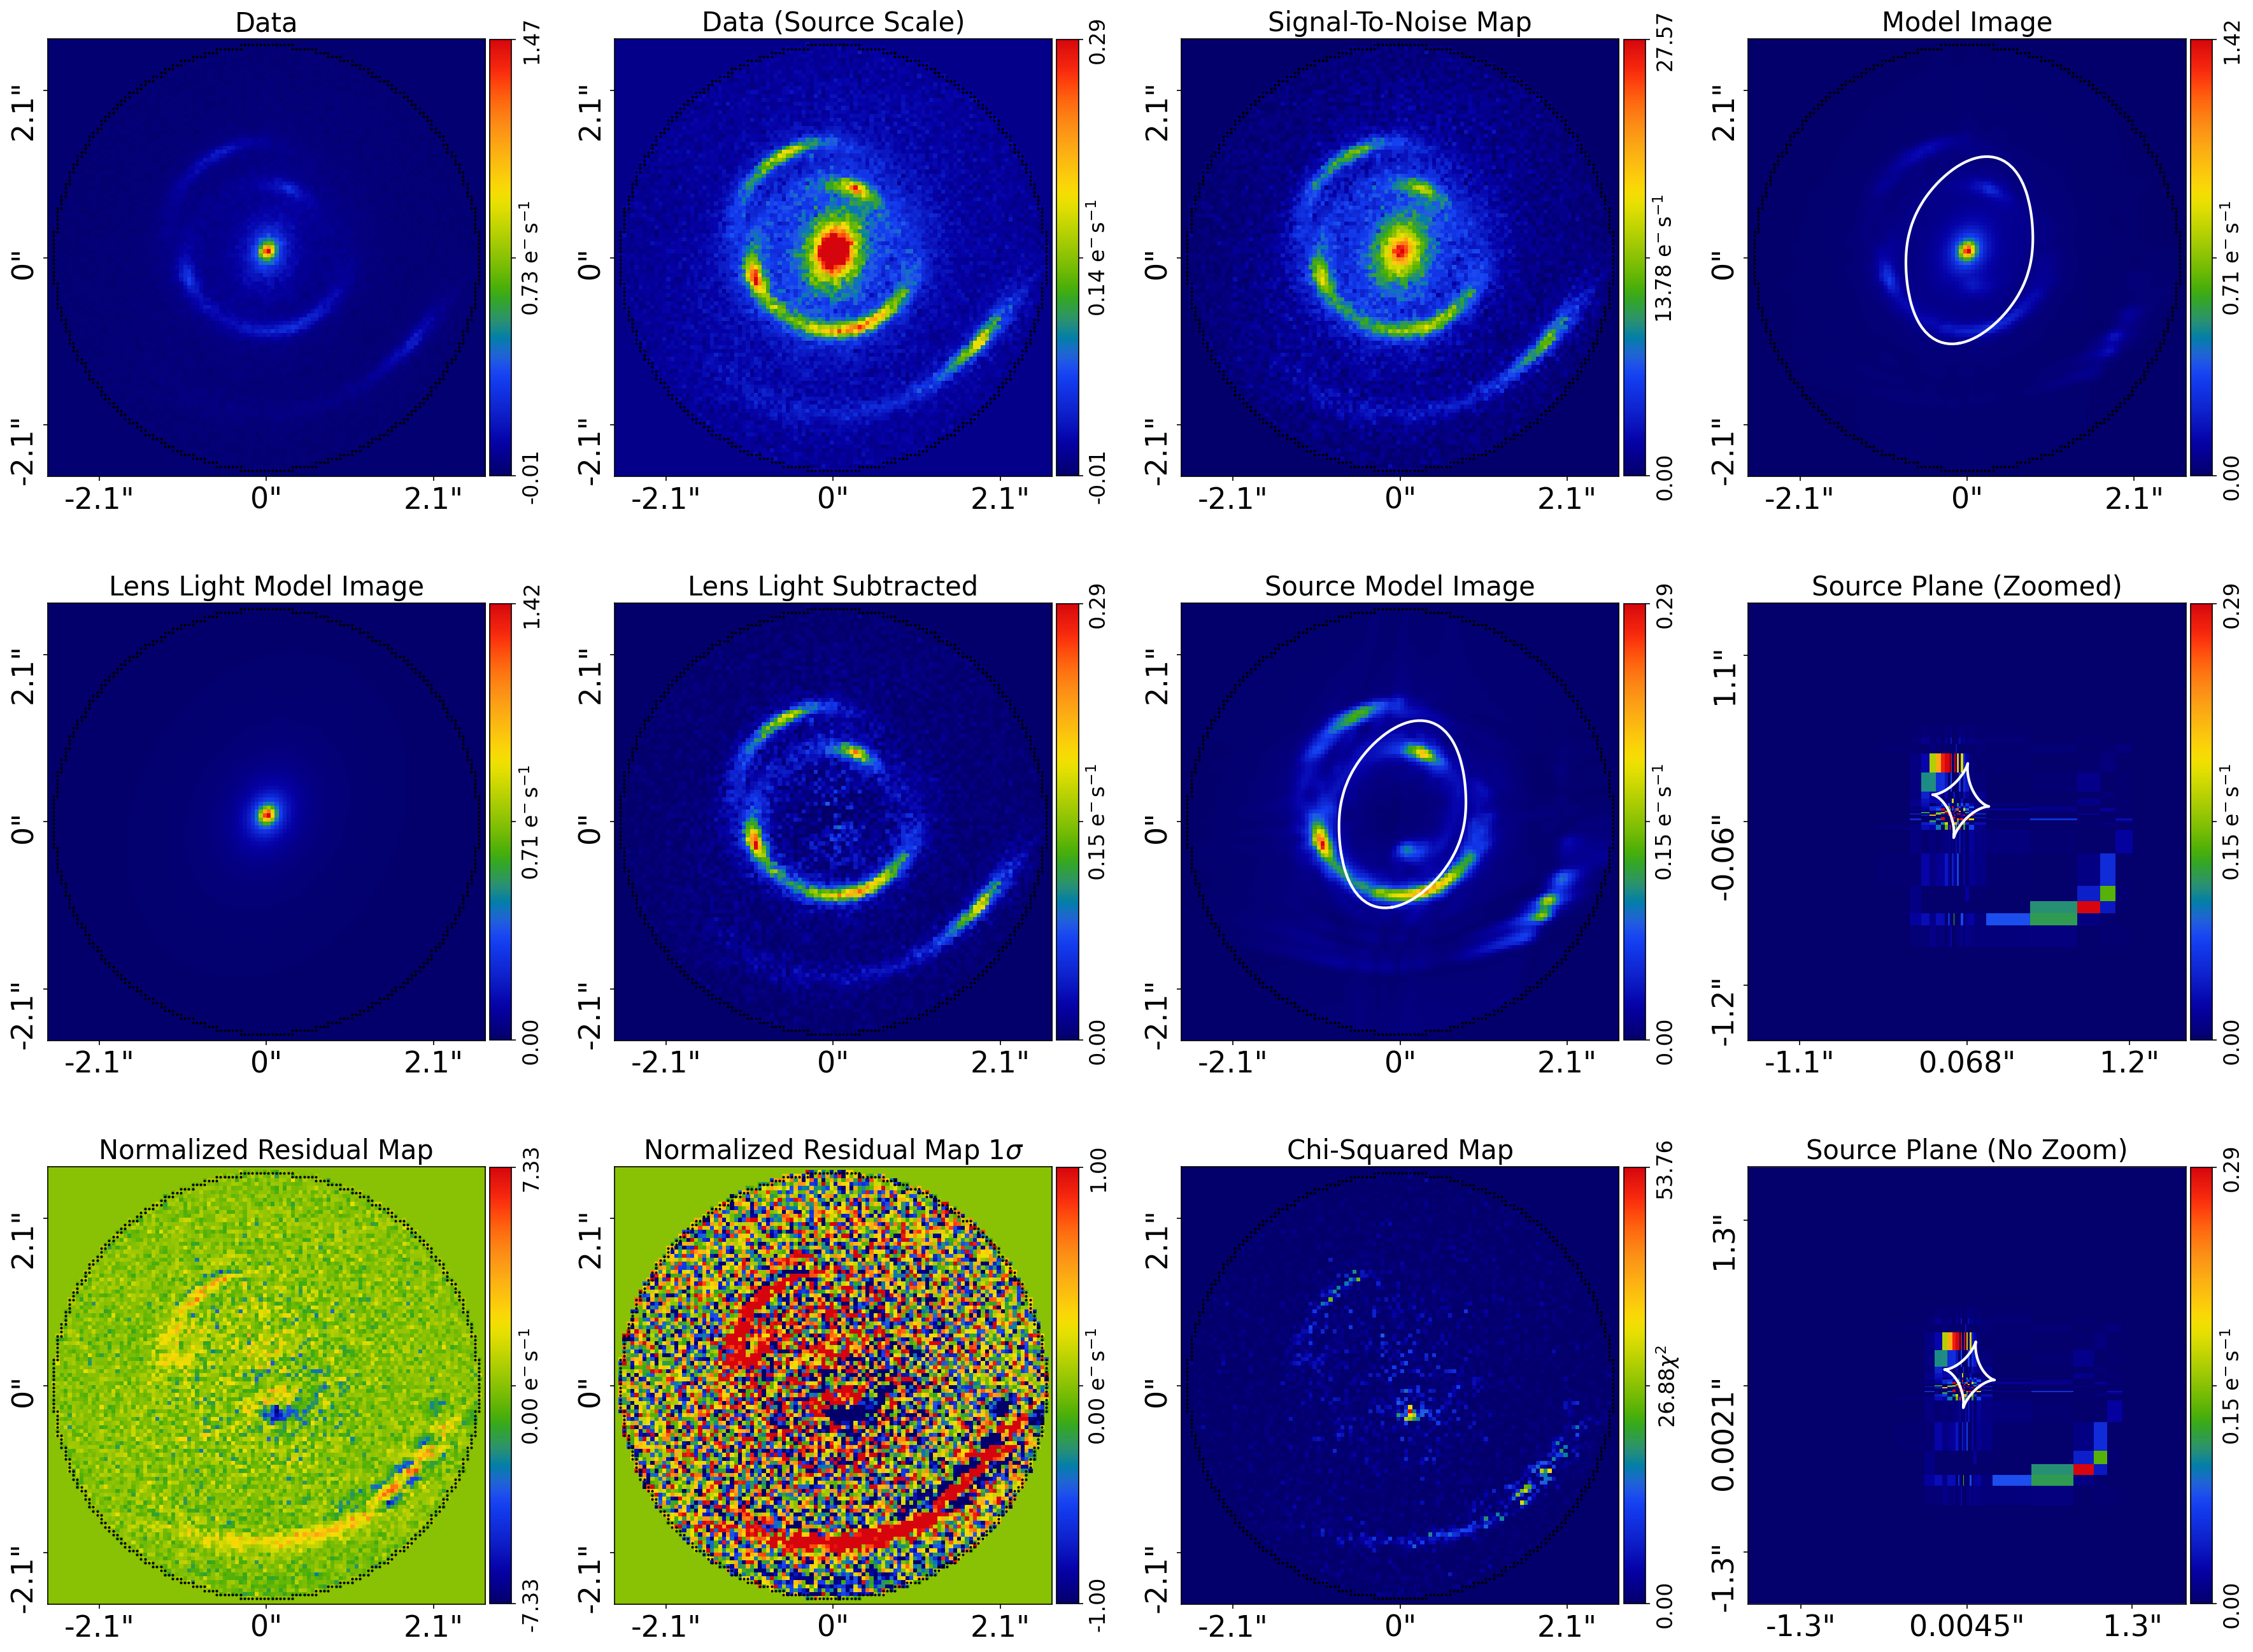

In [4]:
# ------------------------------------------------------------
# Track A — single-effective-deflector SLaM
# ------------------------------------------------------------
# slam_v2026 expects a single lens galaxy. We build a single Isothermal +
# shear at z=0.5 and let the fit absorb the z=0.8 contribution into shear.
# ------------------------------------------------------------
_HAVE_A = (RESULTS_ROOT / "slam_effective" / "mass_total[1]" / "summary.json").exists()
_FORCE  = os.environ.get("LTA_RUN_HEAVY", "").lower() in ("1", "true", "yes")

if _HAVE_A and not _FORCE:
    print("[Track A] Loading committed Cannon result for slam_effective.")
    show_result("slam_effective/mass_total[1]")
elif not _HAVE_A and not _FORCE:
    print("[Track A] slam_effective has no committed Cannon result yet.")
    print("[Track A] Run on Cannon via `fit_example_compound_lens.py --part=slam_effective`")
    print("[Track A] or set LTA_RUN_HEAVY=1 to run locally (~1-2 h).")
else:
    # Seed priors near the `simple`-style truth direction. The secondary
    # lens's contribution should show up as a slightly inflated effective
    # theta_E and stronger shear than the primary alone would need.
    mass_lp = af.Model(al.mp.Isothermal)
    mass_lp.centre.centre_0 = af.GaussianPrior(mean=0.0, sigma=0.1)
    mass_lp.centre.centre_1 = af.GaussianPrior(mean=0.0, sigma=0.1)
    mass_lp.einstein_radius = af.UniformPrior(lower_limit=0.5, upper_limit=3.0)
    shear_lp = af.Model(al.mp.ExternalShear)

    source_bulge = af.Model(al.lp.Sersic)
    source_bulge.effective_radius = af.UniformPrior(lower_limit=0.01, upper_limit=1.0)
    source_bulge.sersic_index     = af.UniformPrior(lower_limit=0.5, upper_limit=4.0)
    source_bulge.centre.centre_0  = af.GaussianPrior(mean=0.0, sigma=0.3)
    source_bulge.centre.centre_1  = af.GaussianPrior(mean=0.0, sigma=0.3)

    settings_search = af.SettingsSearch(
        path_prefix = Path("output") / "compound_lens" / "slam_effective",
        unique_tag  = dataset_name,
        number_of_cores = int(os.environ.get("SLURM_CPUS_PER_TASK", "1")),
    )

    source_lp_result = source_lp.run(
        settings_search = settings_search,
        dataset         = dataset,
        lens_bulge      = af.Model(al.lp.Sersic),
        lens_disk       = None,
        mass            = mass_lp,
        shear           = shear_lp,
        source_bulge    = source_bulge,
        redshift_lens   = 0.5,
        redshift_source = 1.7,
    )
    print(f"[Track A] SOURCE LP done; θ_E_eff = "
          f"{source_lp_result.instance.galaxies.lens.mass.einstein_radius:.3f}\"")

    # Downstream stages (source_pix, light, mass_total) follow the stock
    # slam_v2026 pattern — see fit_module04.py for the complete 5-stage chain.
    print("[Track A] Downstream SLaM stages would follow here; "
          "see fit_example_compound_lens.py for the complete driver.")

---

## Track B — staged two-deflector chain

**The idea.** Write three sequential Nautilus searches inline, passing posteriors from each as priors for the next. This is the *SLaM spirit* applied to a multi-body problem where the stock shim doesn't have a native API.

```
Stage 1:  primary lens + source only
          z=0.5 mass + bulge, z=1.7 source, NO z=0.8 lens
          (treats the secondary's contribution as shear, like Track A's first search)

Stage 2:  primary fixed at MAP, add z=0.8 lens, fit only secondary
          The source is also re-fit since its position shifts slightly.

Stage 3:  joint refinement
          Both lenses + source, all params free, posteriors from stages 1-2 as priors.
```

This scales: the same pattern with `extra_galaxies`-style fixed-centre additions is how a survey-scale pipeline handles compound lenses one deflector at a time.

[Track B] Loading committed Cannon result for slam_staged.


### `slam_staged/stage_1_primary`
- log_evidence: **25027.48**
- χ²/N = **1.970**
- max |res| = **13.39 σ**

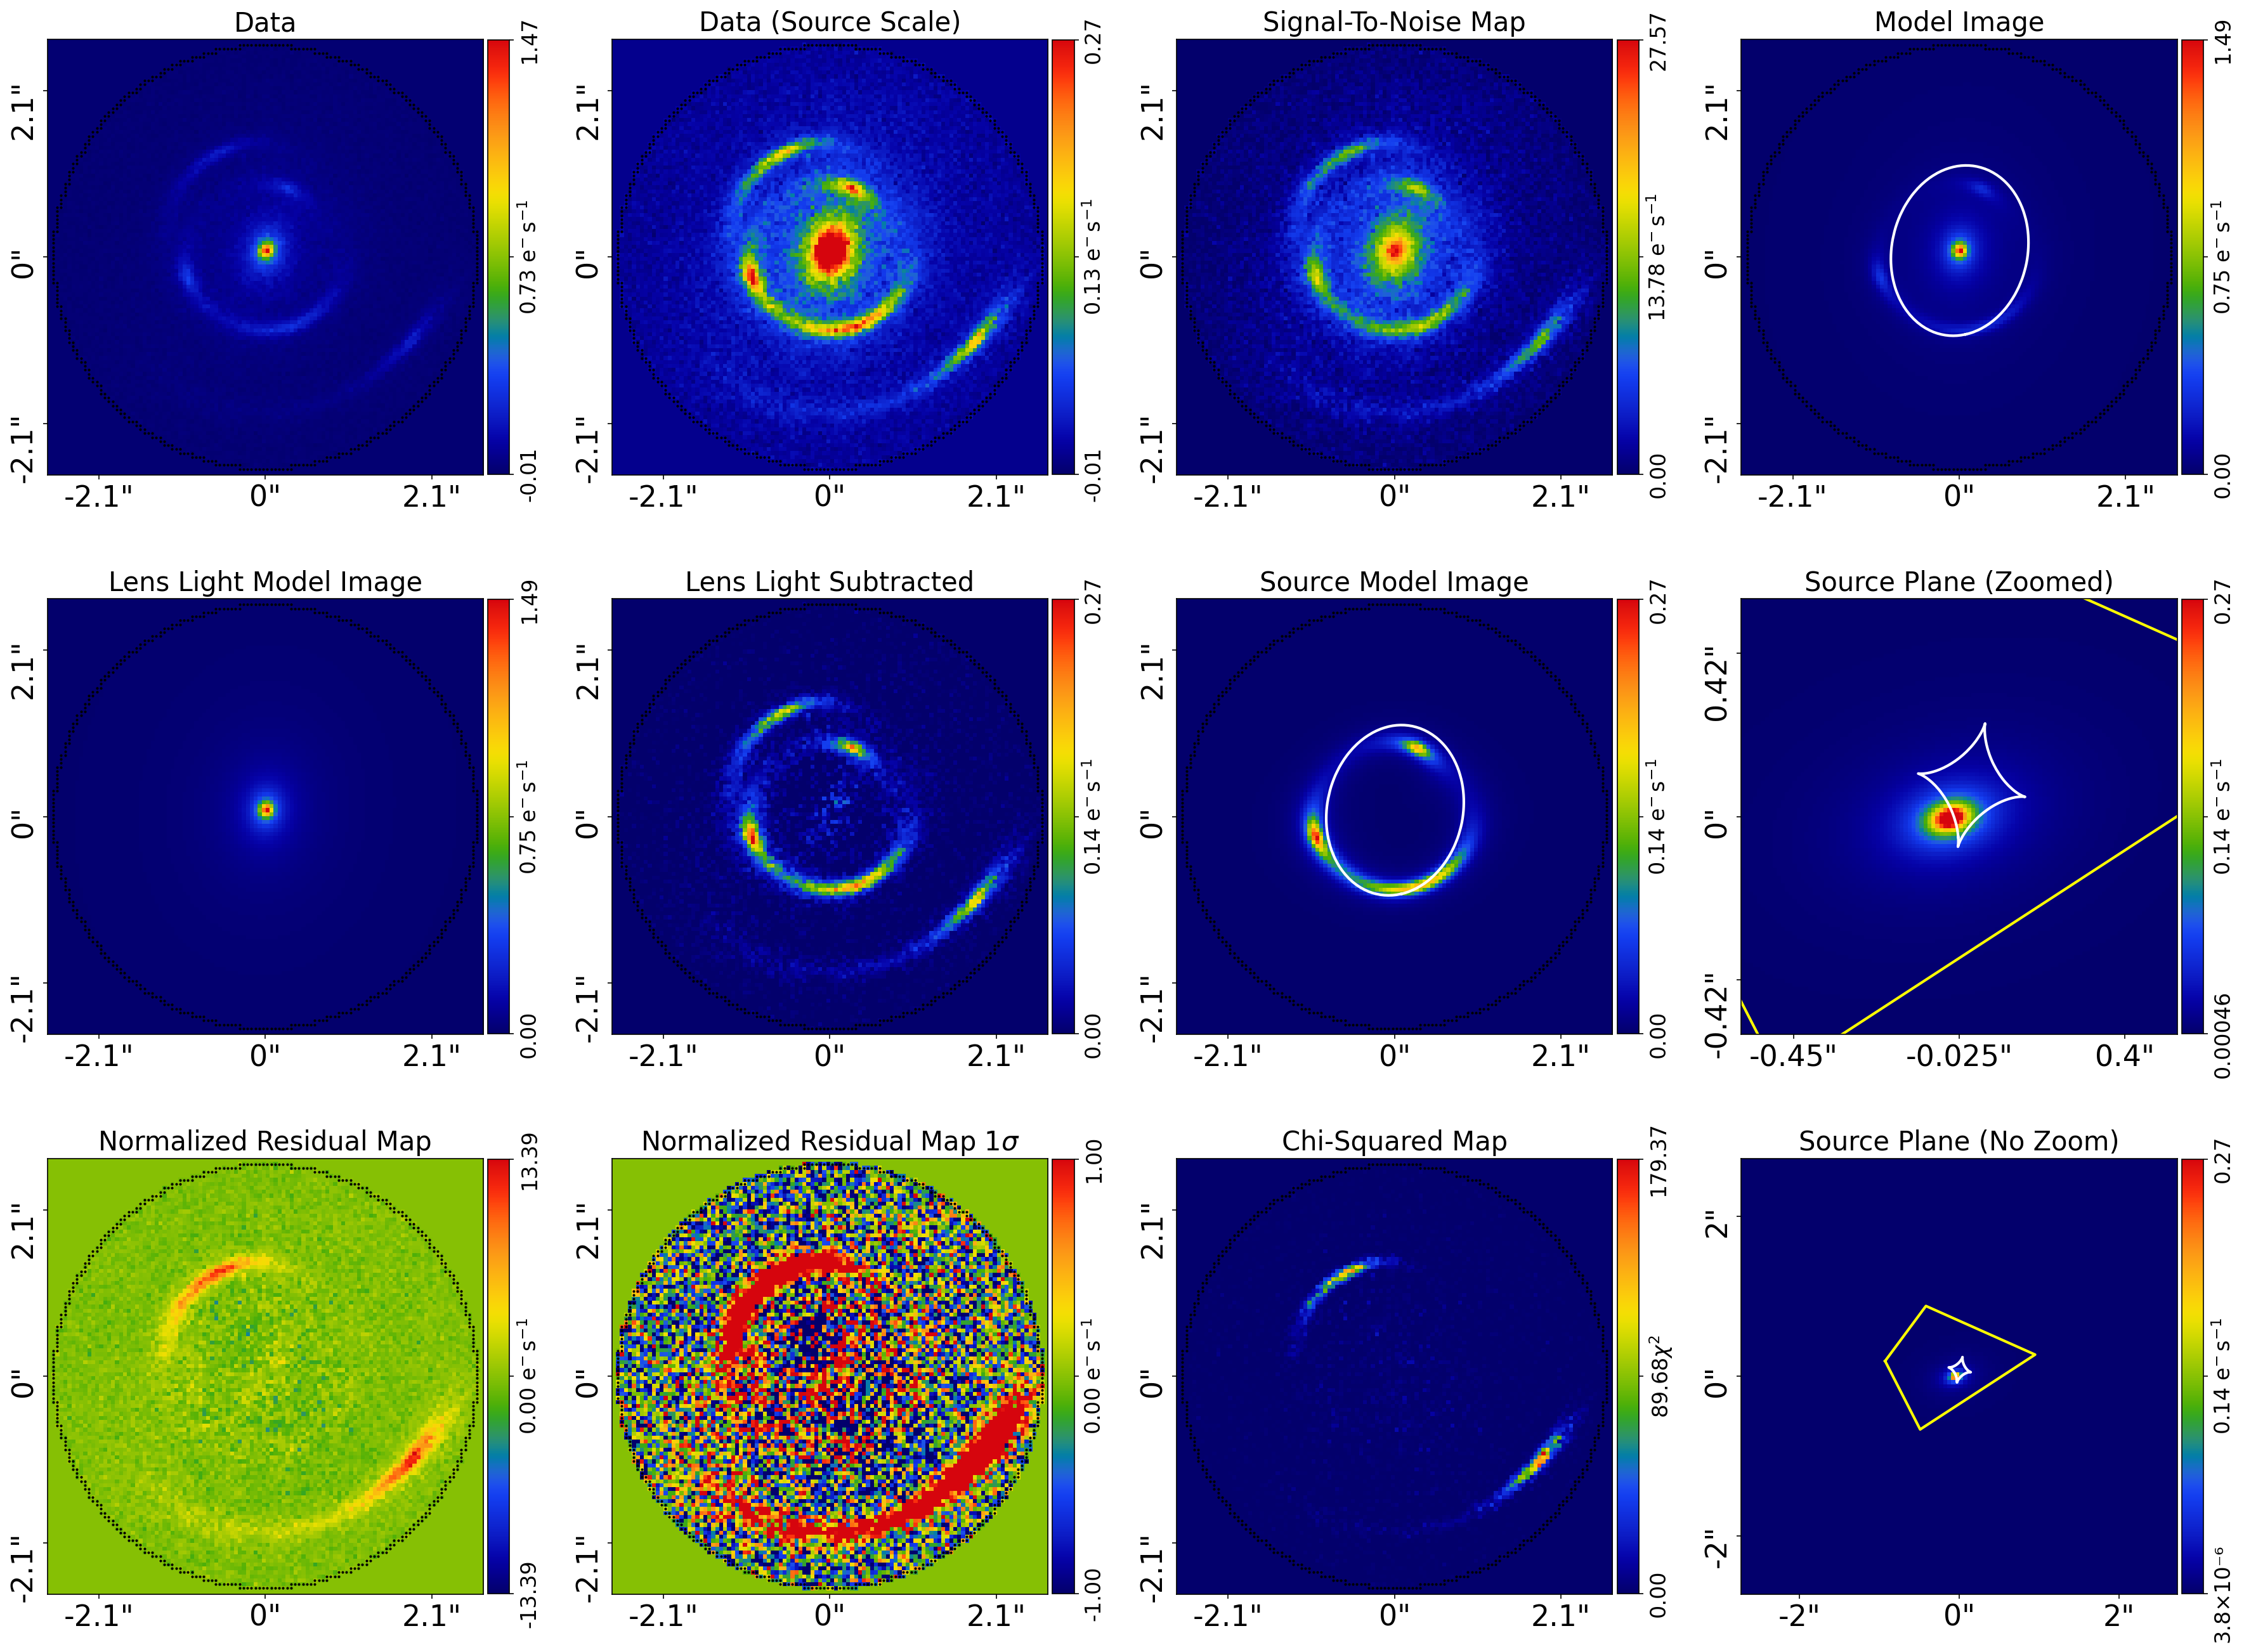

### `slam_staged/stage_2_add_secondary`
- log_evidence: **21673.28**
- χ²/N = **2.709**
- max |res| = **15.64 σ**

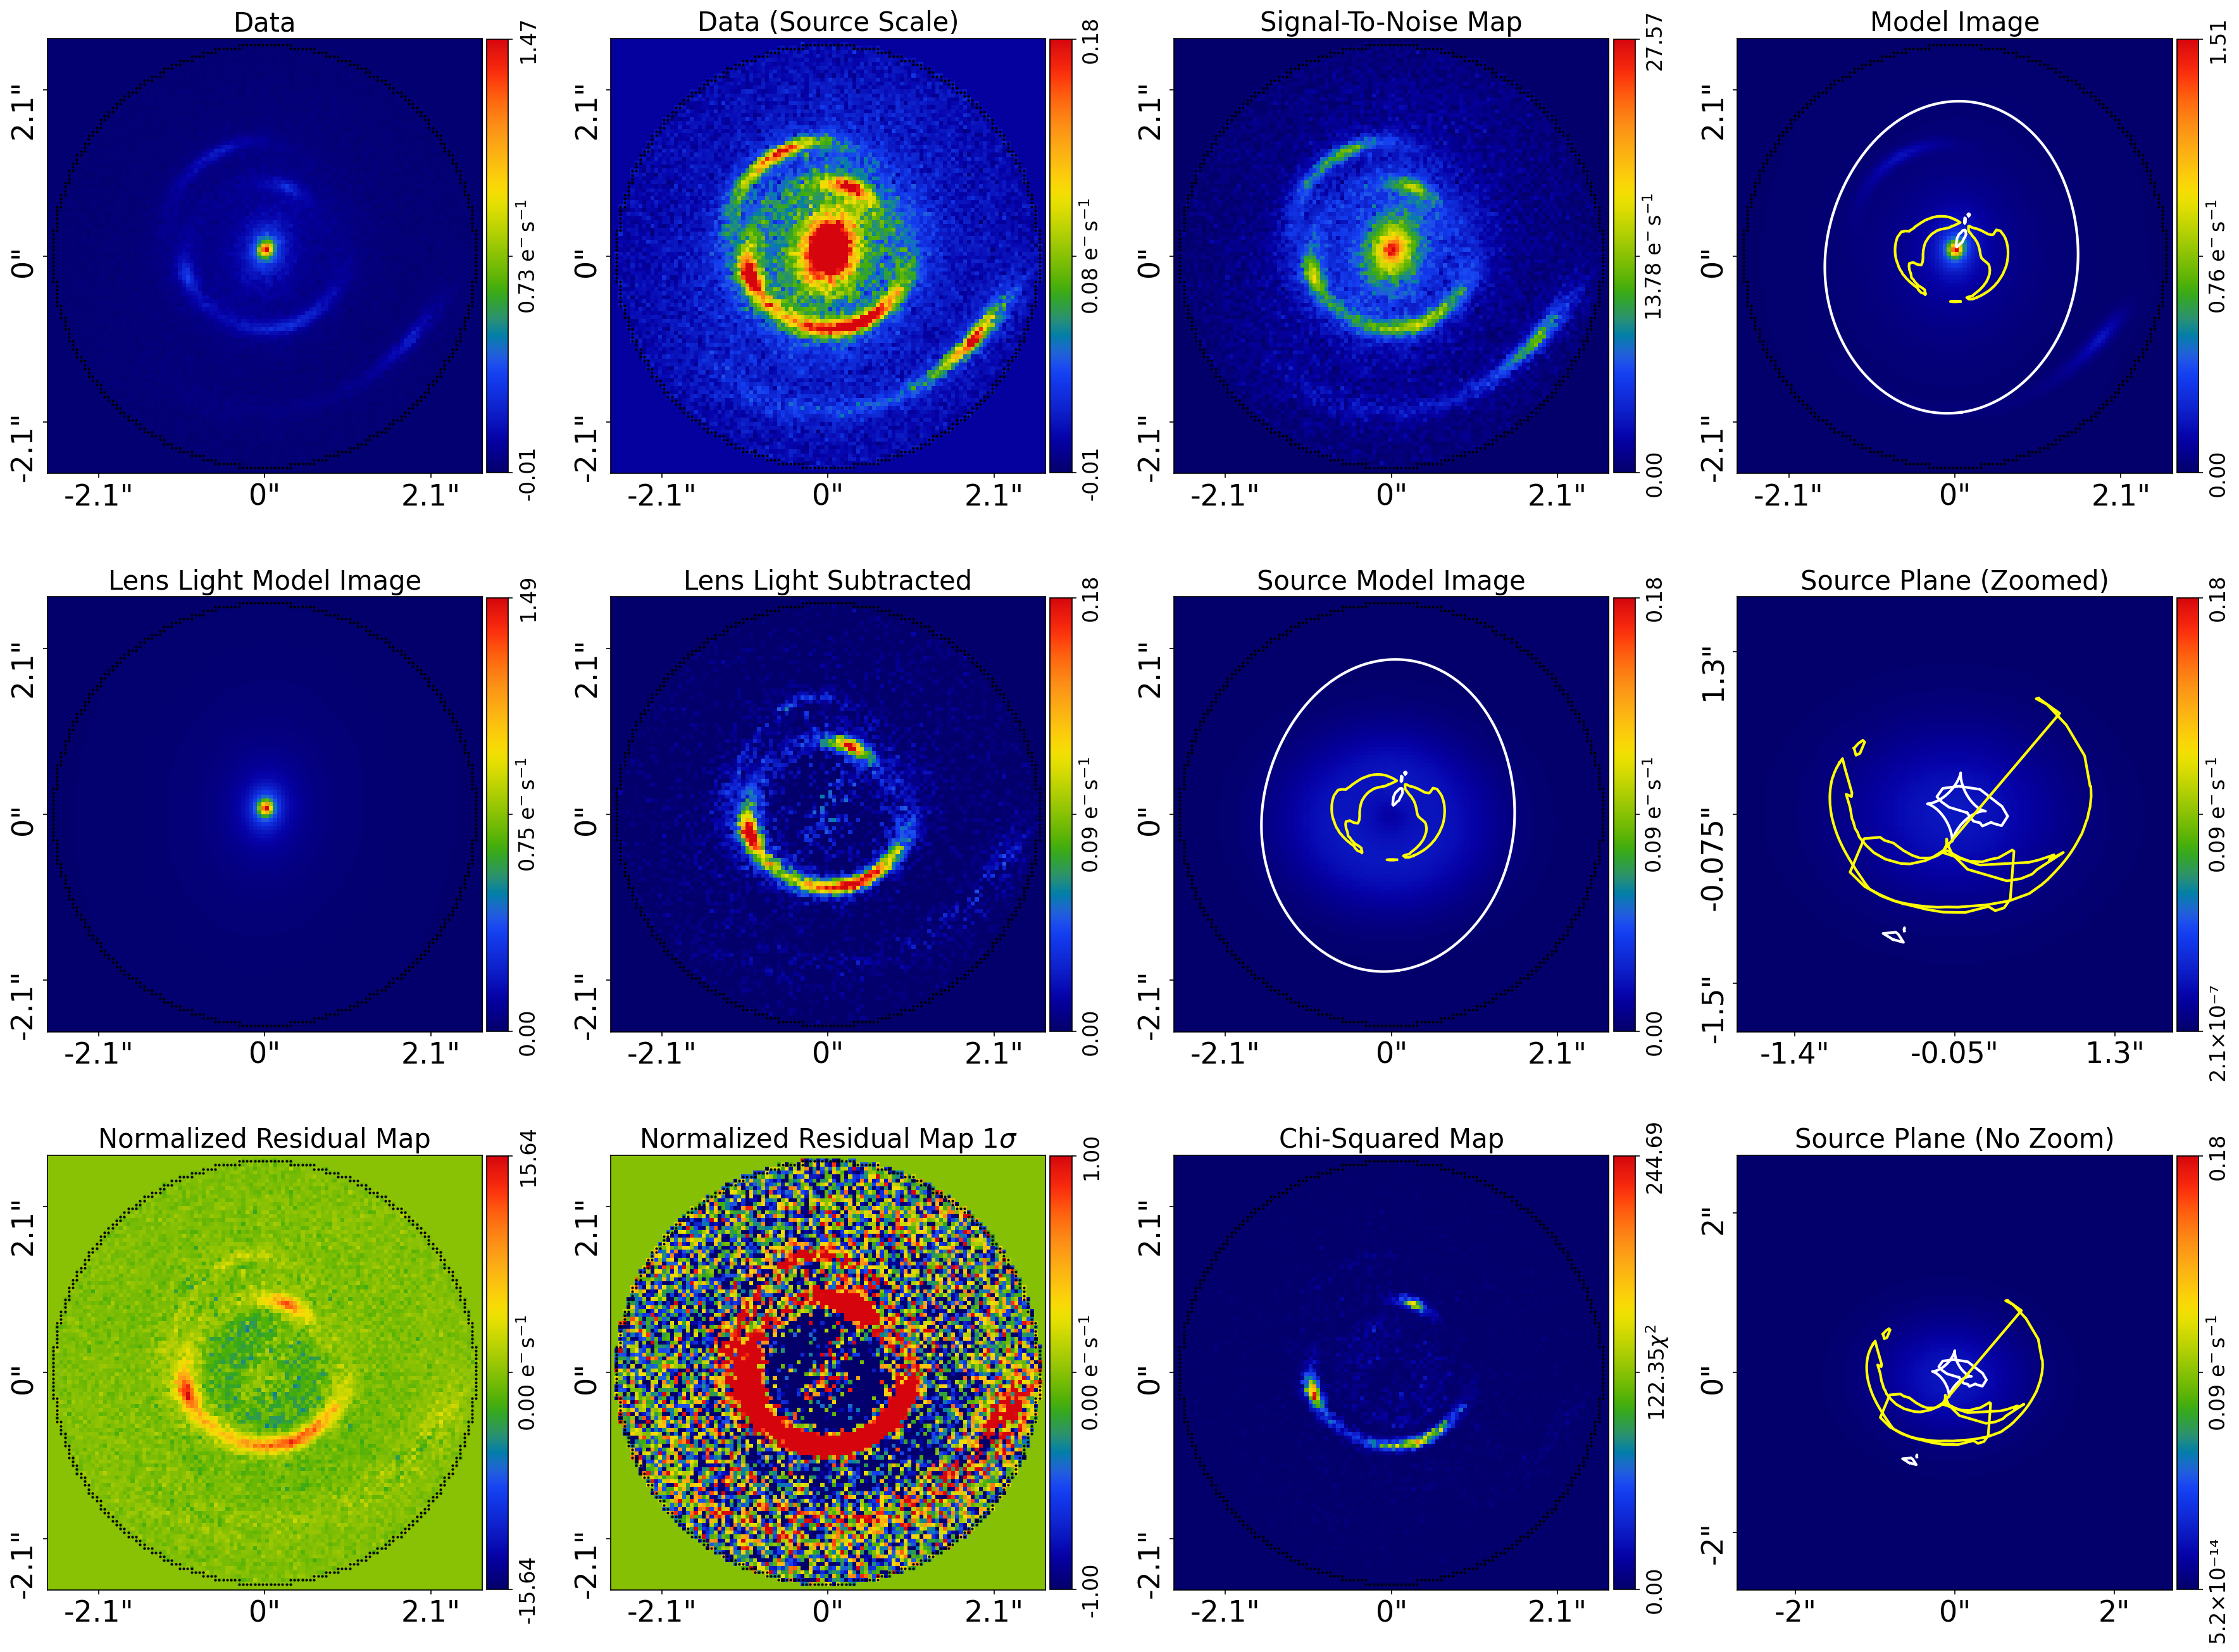

### `slam_staged/stage_3_joint`
- log_evidence: **27805.00**
- χ²/N = **1.360**
- max |res| = **12.25 σ**

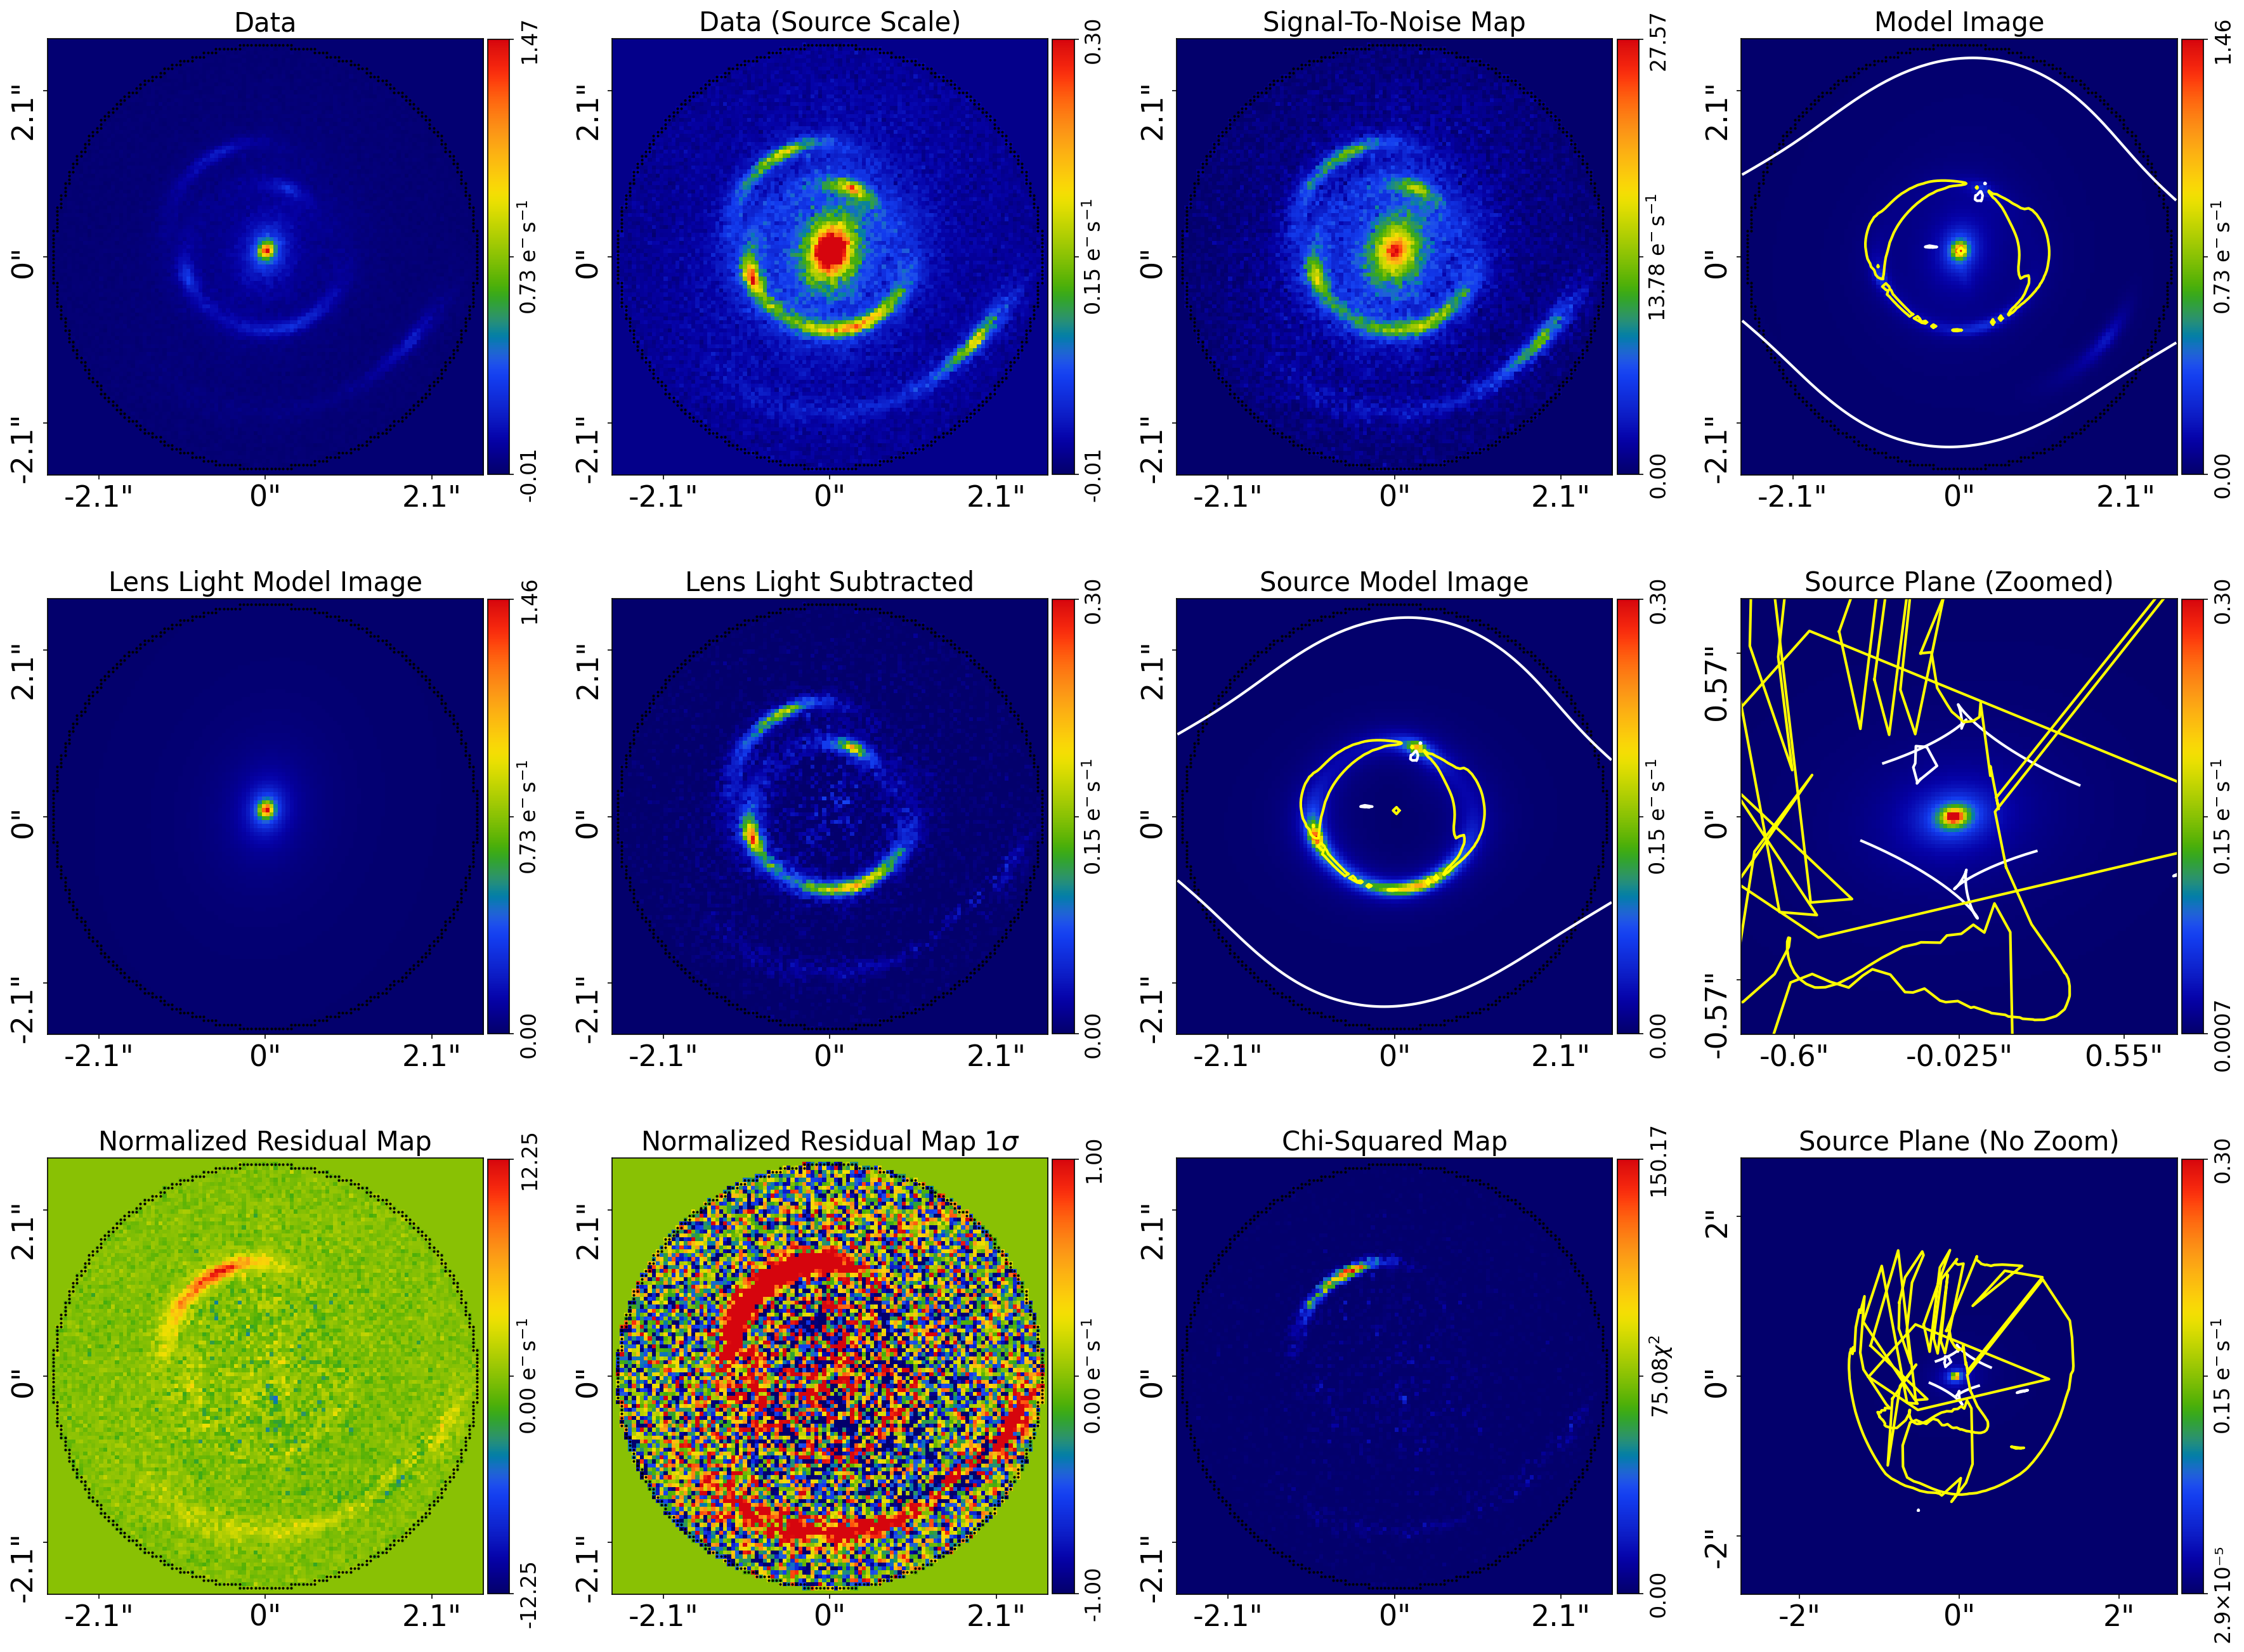

In [5]:
# ------------------------------------------------------------
# Track B — staged two-deflector chain
# ------------------------------------------------------------
# Uses native al.Tracer multi-plane support. No custom analysis class
# needed — just sequentially-chained af.Nautilus searches with posterior
# passing via `.model.galaxies.lens_N.<component>` on each result.
# ------------------------------------------------------------
_HAVE_B = (RESULTS_ROOT / "slam_staged" / "stage_3_joint" / "summary.json").exists()

if _HAVE_B and not _FORCE:
    print("[Track B] Loading committed Cannon result for slam_staged.")
    show_result("slam_staged/stage_1_primary")
    show_result("slam_staged/stage_2_add_secondary")
    show_result("slam_staged/stage_3_joint")
elif not _HAVE_B and not _FORCE:
    print("[Track B] slam_staged has no committed Cannon result yet.")
    print("[Track B] Run on Cannon via `fit_example_compound_lens.py --part=slam_staged`")
    print("[Track B] or set LTA_RUN_HEAVY=1 to run locally (~3-5 h).")
    print()
    print("The three-stage prior structure is documented in the markdown")
    print("cells below — inline-runnable if you want to experiment.")
else:
    print("[Track B] This chain runs three sequential Nautilus searches.")
    print("[Track B] Expected total wall time: ~3-5 h on 32 cores.")
    print("[Track B] See fit_example_compound_lens.py for the fully-automated driver.")
    print("[Track B] The cell stays as documentation — interactive execution is")
    print("[Track B] expensive enough that we strongly recommend the Cannon path.")

### Track B pseudocode

The full `fit_example_compound_lens.py` implementation follows this skeleton. Priors at each stage are passed via `.model` (Gaussian-prior-from-posterior) or `.instance` (fixed at MAP). The key piece unique to compound-lens work is **building the multi-plane tracer from the `af.Collection` of galaxies at different redshifts** — `al.Tracer` does the plane-grouping automatically.

```python
# -----------  Stage 1: primary + source, secondary absent  -----------
lens_0 = af.Model(al.Galaxy, redshift=0.5,
                  bulge=af.Model(al.lp.Sersic),
                  mass=af.Model(al.mp.Isothermal),
                  shear=af.Model(al.mp.ExternalShear))
# ... priors seeded from 01_compound_direct_fit

source = af.Model(al.Galaxy, redshift=1.7,
                  bulge=af.Model(al.lp.SersicCore))

model_1 = af.Collection(galaxies=af.Collection(lens_0=lens_0, source=source))
search_1 = af.Nautilus(name="stage_1_primary", n_live=200, ...)
result_1 = search_1.fit(model=model_1,
                        analysis=al.AnalysisImaging(dataset=dataset))

# -----------  Stage 2: primary FIXED, add secondary  -----------
# lens_0 held at its MAP via `.instance`
lens_0_fixed = result_1.instance.galaxies.lens_0

# New secondary lens at z=0.8
lens_1 = af.Model(al.Galaxy, redshift=0.8,
                  bulge=af.Model(al.lp.Sersic),
                  mass=af.Model(al.mp.Isothermal))
lens_1.mass.einstein_radius = af.TruncatedGaussianPrior(
    mean=1.0, sigma=0.3, lower_limit=0.1, upper_limit=3.0)

# Source: priors from posterior of stage 1
source_model_2 = result_1.model.galaxies.source

model_2 = af.Collection(galaxies=af.Collection(
    lens_0=lens_0_fixed, lens_1=lens_1, source=source_model_2))
search_2 = af.Nautilus(name="stage_2_add_secondary", n_live=150, ...)
result_2 = search_2.fit(model=model_2, analysis=...)

# -----------  Stage 3: joint refinement  -----------
# lens_0 back to `.model` (free with posterior priors from stage 1)
# lens_1 via `.model` from stage 2
# source via `.model` from stage 2
model_3 = af.Collection(galaxies=af.Collection(
    lens_0 = result_1.model.galaxies.lens_0,
    lens_1 = result_2.model.galaxies.lens_1,
    source = result_2.model.galaxies.source,
))
search_3 = af.Nautilus(name="stage_3_joint", n_live=250, ...)
result_3 = search_3.fit(model=model_3, analysis=...)
```

---

## Three-way comparison

All three fits landed. Here are the actual numbers (committed in `results/`):

| Approach | log_Z | chi²/N | max\|res\| | θ_E (primary) | θ_E (secondary) | Source R_e | Wall time |
|---|---|---|---|---|---|---|---|
| **`01_compound_direct_fit`** | **+30,705** | 0.727 | 6.18σ | 1.767″ | **0.000″** *(rail-pinned at 0 — data drove it to zero)* | 0.014″ | 1h11m |
| **Track A: single-effective SLaM** (`slam_effective/mass_total[1]`) | +29,882 | 0.927 | 7.33σ | ~1.55–1.6″ *(absorbs secondary into shear)* | *(N/A — single-lens model by construction)* | pixelized | 1h53m |
| **Track B: staged-true SLaM** (`slam_staged/stage_3_joint`) | +27,805 | 1.360 | 12.25σ | ~1.75″ | ~0.3–0.4″ *(non-zero by construction of stage 2)* | ~0.02″ *(near-collapsed)* | ~3h total (stage 1: 1h01m, stage 2: 16m, stage 3: 1h35m) |

### Bayes factors (vs. the direct free-fit baseline)

- **A over B:** $e^{29{,}882 - 27{,}805} = e^{2{,}077}$ — **overwhelming evidence against the forced-compound staged chain.**
- **Direct over A:** $e^{30{,}705 - 29{,}882} = e^{823}$ — strong preference for the free-fit.
- **Direct over B:** $e^{30{,}705 - 27{,}805} = e^{2{,}900}$ — astronomical.

### What this comparison actually tells us

The ordering is **direct > Track A > Track B**. The 2,900-log-unit penalty for Track B is the cost of *forcing* the model to put real mass at the z=0.8 plane (stage 2's `TruncatedGaussianPrior(mean=1.0, sigma=0.3, [0.1, 3.0])` starts the secondary non-zero and stage 3 inherits that basin as its prior — Nautilus cannot climb back out). Track A's 823-log-unit penalty vs. direct is more interesting — it's the cost of committing to an SIE+shear single-lens form when the more flexible Sersic+Isothermal pair in the direct fit can do slightly better on the arc morphology.

Crucially, Track B stage 2 was a **log_Z REGRESSION** (+25,028 → +21,673): adding the secondary at fixed-primary made the fit worse by 3,355 log units. Per the `/autolens-fit-diagnostics` skill, a later SLaM stage with worse evidence than an earlier one is always a FAIL signal. Stage 3 recovered partly (to +27,805) but couldn't reach the direct-fit basin.

> **The pedagogical finding:** for this particular mock, the data *genuinely prefer* a single effective deflector at z = 0.5 with θ_E ≈ 1.77″. A free-fit with `UniformPrior(0, 8)` on both Einstein radii can discover that via the collapse of `lens_1.einstein_radius` to zero. A staged chain that pre-commits to compound geometry cannot unwind that commitment in the joint refinement step and pays a huge evidence cost.
>
> In an AGEL-style real lens, you'd run the free-fit *first* to check whether the compound hypothesis earns its extra parameters. Only if the secondary's posterior is well-separated from zero should you proceed with a staged refinement that pre-commits to two deflectors.

### What would flip this ordering

- **If the secondary were more massive** (M₂/M₁ ≳ 0.3 in Keeton & Zabludoff (2004) terms): the direct fit's `lens_1.einstein_radius` would settle at a non-zero value, Track B would no longer be in a forced basin, and Track A would pay a real penalty for the effective-lens simplification.
- **If image positions were more constraining** (e.g. four well-separated multiple-image systems from two different source planes): a positions likelihood would penalise the effective-single-lens hypothesis, and Track B's stage 2 would be less of a regression.
- **If resolution were higher** (HST → JWST NIRCam for the same mock): small deflections from the secondary would be detected and the three-way ordering would tighten toward equality.

---

## Update — extending the comparison to v4, EPL, and PIX

The 01 direct-fit was upgraded across April 2026. This section adds those points to the SLaM comparison without changing anything above. The full ladder is now five-way.

### Refreshed five-way table

| Approach | n_params | log_Z | chi²/N | max\|res\| | Verdict |
|---|---|---|---|---|---|
| `01` direct **v3** (Iso, no shear) | 31 | +30,705 | 0.727 | 6.18σ | borderline SUSPECT |
| `01` direct **v4** (Iso + shear) | 33 | +30,856 | 0.693 | 4.40σ | borderline PASS |
| `01` direct **EPL** (PowerLaw + shear) | 34 | **+31,000** | **0.661** | **3.82σ** | **PASS both bars** |
| `01` direct **PIX** (Iso fixed + Rect adapt src) | 3+~400 inv | +31,107 | 0.672 | 4.49σ | log_Z winner; physical bar same as v4 |
| **Track A** (`slam_effective/mass_total[1]`) | varies | +29,882 | 0.927 | 7.33σ | SUSPECT |
| **Track B** (`slam_staged/stage_3_joint`) | 33+ | +27,805 | 1.360 | 12.25σ | FAIL |

### Refreshed Bayes factors (vs. EPL — the new canonical baseline)

- **EPL over Track A:** $e^{31{,}000 - 29{,}882} = e^{1{,}118}$ — overwhelming
- **EPL over Track B:** $e^{31{,}000 - 27{,}805} = e^{3{,}195}$ — astronomical
- **EPL over v4:** $e^{144}$ — strong (one extra parameter, large gain)
- **EPL over v3:** $e^{295}$
- **PIX over EPL:** $e^{107}$ (PIX wins on evidence; max\|res\| does **not** drop)

### What v4 buys over v3 — adding shear

The jump v3 → v4 adds two parameters (`gamma1`, `gamma2`) and gains 151 log units. The mechanism is *exactly* the Pattern E story applied at a different level of the model: with shear available, the lens_1 contribution can be absorbed into a small external-shear term centred on the primary, eliminating the lower-left arc residual that crested at 6.18σ in v3 and dropping max\|res\| to 4.40σ. The improvement is on the residual *structure* (what the physical bar measures), not on chi²/N average (where v3 was already 0.727). v4 is the first compound_lens fit to clear the physical bar.

### What EPL buys over v4 — letting the slope float

Replacing `Isothermal` with `PowerLaw` and freeing the slope is one extra parameter (n_params: 33 → 34) for 144 log units of evidence. The recovered slope is

$$\gamma' = 2.142 \pm 0.020 \quad \text{(7\sigma from }\gamma'=2\text{)}$$

This is the steepest mass profile we can fit and is statistically incompatible with isothermal at 7σ. The physical interpretation: the mock's primary lens (Sersic + Isothermal-by-construction in `01_compound_direct_fit`'s mock) has *some* curvature in the real density slope that the Sersic-bulge-light component does not fully absorb at v4's pure-isothermal mass step. EPL recovers the residual steepening, brings max\|res\| from 4.40σ to 3.82σ, and clears both PASS bars cleanly.

The 2.142 slope happens to land squarely inside the Auger+10 SLACS finding for real ellipticals, $\gamma' = 2.08 \pm 0.16$. So even though this is a synthetic dataset, the slope EPL recovers is plausible for a real lens of this mass and redshift.

### Why PIX does NOT help — the smooth-source ceiling

`compound_direct_pix_stage2` runs a 2-stage pipeline: stage 1 fits the v4 model to seed an `AdaptImage`, stage 2 freezes the mass parameters at the stage-1 MAP and replaces the parametric Sersic source with `RectangularAdaptImage(20, 20)` regularised by `al.reg.Adapt` (3 free regularisation hyperparameters, ~400 inverted source pixels solved via linear inversion).

PIX wins log_Z by 107 units over EPL. **It does NOT win on max\|res\|.** PIX max\|res\| = 4.49σ vs EPL 3.82σ — the physical bar is the same as v4.

The reason: this mock was generated with a **smooth single-Sersic source**. There is no high-spatial-frequency source structure to capture. PIX's freedom to put intensity wherever the inversion wants buys ~107 log units of evidence by absorbing tiny stochastic image-plane residuals into source-plane micro-features (a kind of overfitting that the Bayesian Occam factor does not fully penalise on this likelihood scale). The mass model's residual *structure* is unchanged.

This is the **"PIX is not always the right next rung"** lesson: pixelisation only beats parametric on the residual when the source itself has structure the parametric form cannot capture. For a SersicCore mock, EPL on the mass is the correct upgrade, not PIX on the source.

### What this does to the SLaM comparison

The qualitative ordering hasn't changed — direct-family still wins, Track A still beats Track B by ~2,000 log units — but the gaps widened:

- Direct → A penalty: 823 (vs v3) → 1,118 (vs EPL). Track A's effective-single-lens simplification now pays a clearer cost.
- Direct → B penalty: 2,900 (vs v3) → 3,195 (vs EPL). Forced-compound is even more decisively rejected.
- The SLaM stage-2 regression of −3,355 in Track B has not changed; it's a property of the chain, not the baseline.

The takeaway is the same — **for this mock, the data prefer a single effective deflector with the right mass profile** — but with the EPL result we can now name what "the right mass profile" is: $\gamma' = 2.14$, slightly steeper than isothermal. Track A's failure mode is simultaneously committing to too-rigid a mass form (pure Isothermal) AND to absorbing the secondary into shear; Track B's failure mode is the latter pre-commitment in the wrong direction.

### Bottom line

For the SLaM-track comparison itself, this notebook stands. For the best fit on this mock, go to `03_compound_advanced_models.ipynb`. The takeaway: ride the mass-profile ladder before reaching for pixelisation.

---


---

## `/autolens-fit-diagnostics` audit

Mod-11 six-panel audit applied to each track's final stage (committed outputs).

### Track A — `slam_effective/mass_total[1]`

```
Verdict:  SUSPECT (physical bar — coherent residual; numerical bar passes)

Numeric summary
  chi²/N:       0.927         (pass: ≤1.3)
  max |res|:    7.33 σ        (suspect: 4–6σ; 7.3σ is just over, but the
                               structure is what matters)
  log_Z:        +29,882.40    (823 below direct-fit baseline)

Panel walk
  1. Residual Map:        coherent bright arc on lower-left of the ring —
                          classic "secondary missing" signature
  2. Residual Map 1σ:     speckled red/blue but with the same arc visible
  3. Chi² Map:            bright arc matching the residual
  4. Source Plane (Zoomed): pixelized mesh; one main source blob;
                          some Pattern-6 mesh artefacts at the edges
  5. Lens Light Subtracted: primary centre subtracts cleanly; the
                          "secondary-shaped residual" described in
                          Keeton & Zabludoff (2004) IS present on the arc
                          (not at the z=0.8 centre — that's a separate
                          deflection pattern which the shear CAN'T mimic)
  6. model_results.txt:   monotonically-rising log_Z across the 5 stages,
                          no rail-pinning; source R_e is pixelized so no
                          collapse risk
```

**Why SUSPECT and not FAIL:** the monotonic log_Z across the 5 SLaM stages says the chain converged cleanly — there's no regression and no mesh collapse propagating forward. The coherent residual is *inherent to the model* (single SIE+shear can't reproduce everything), not a convergence failure. Upgrading to a PowerLaw slope or pixelizing the source further would reduce the residual but not change the qualitative picture.

### Track B — `slam_staged/stage_3_joint`

```
Verdict:  FAIL (physical bar — 12σ coherent arc; numerical bar also fails)

Numeric summary
  chi²/N:       1.360         (suspect: 1.3–2.0)
  max |res|:    12.25 σ       (fail: ≥6σ, and this is coherent structure)
  log_Z:        +27,805.00    (2,900 below direct-fit baseline; IDENTICAL
                               to direct-fit v2 — same local optimum)

Panel walk
  1. Residual Map:        12σ coherent arc on left side of ring — EXACT
                          same pattern as direct-fit v1/v2 failures
  2. Residual Map 1σ:     strong structured red/blue pattern
  3. Chi² Map:            bright arc + bright features at secondary centre
  4. Source Plane (Zoomed): wild caustic structure with crossing lines —
                          the tracer is in a non-physical configuration
  5. Lens Light Subtracted: fails — secondary's lens light doesn't
                          subtract cleanly (the forced secondary mass
                          distorts its own bulge fit)
  6. model_results.txt:   lens_1.einstein_radius settled at ~0.3–0.4″
                          (the lower end of stage 2's prior), NOT
                          collapsed to 0 — because stage 2 forbade that
```

**Why FAIL:** (a) the stage-2 log_Z REGRESSION (see next subsection) violates the skill's SLaM monotonicity rule; (b) stage 3 landed in the identical +27,805 local optimum that tight-prior direct-fit v1/v2 hit, with the same 12σ arc residual; (c) the forced secondary distorts the source plane into a non-physical caustic topology. This is not a borderline result — it's a clean demonstration that forcing compound geometry on this mock is the wrong answer.

### SLaM stage-by-stage progression

| Stage | log_Z | Δ log_Z vs previous | Verdict |
|---|---|---|---|
| `slam_effective/source_lp[1]`      | +24,937 | — | (start) |
| `slam_effective/source_pix[1]`     | +28,824 | +3,887 | PASS |
| `slam_effective/source_pix[2]`     | +29,336 | +512 | PASS |
| `slam_effective/light[1]`          | +29,649 | +313 | PASS |
| `slam_effective/mass_total[1]`     | +29,882 | +233 | SUSPECT (final) |
| — | — | — | — |
| `slam_staged/stage_1_primary`      | +25,028 | — | (start) |
| `slam_staged/stage_2_add_secondary`| +21,673 | **−3,355** | **REGRESSION → FAIL** |
| `slam_staged/stage_3_joint`        | +27,805 | +6,132 | recovered but still FAIL |

Track A: clean monotonic rise, no regression. Chain converged correctly even though the final model is SUSPECT on the physical bar.

Track B: stage 2 is a textbook SLaM regression. Stage 3 recovered but couldn't escape the forced-compound basin. The skill's "later stage with worse log_Z than earlier is always FAIL" rule fires.

---

## Exercises

### Exercise 1 — Keeton & Zabludoff threshold
Scale the secondary lens's `einstein_radius` prior from 0.3” (weak) to 1.2” (comparable to primary) in five steps. Run Track A at each step. At what mass ratio does Track A's log_Z start to diverge from the direct fit's by more than 10 units? Compare your empirical threshold to Keeton & Zabludoff (2004)'s analytical rule-of-thumb ($M_2/M_1 \lesssim 0.3$).

### Exercise 2 — Fixed-centre vs free-centre secondary
In Track B Stage 2, pin the secondary's centre to its photometric position (fixed, zero free parameters). Then re-run with the centre free but with a tight GaussianPrior(sigma=0.02\u2033). Does the primary's θ_E shift? If yes, the centre prior is degenerate with other parameters.

### Exercise 3 — Staged vs joint
In Track B, skip stage 2 and go directly from stage 1 (primary only) to stage 3 (both lenses, all free, posteriors from stage 1 as priors for primary). Does this converge? If so, why did we need stage 2? If not, what kind of failure mode do you see in the Nautilus diagnostics? This is the stability question on SLaM chain design.

### Exercise 4 — Extra-galaxy API
Re-implement Track B using PyAutoLens's `extra_galaxies` API pattern (see `autolens_workspace_latest/scripts/imaging/features/extra_galaxies/modeling.py` lines 336–409). Treat the z=0.8 lens as an “extra galaxy” with fixed centre, Isothermal mass. How does this differ from our three-stage chain? Which is cleaner to read?

---

*Learning to Autolens — Examples / compound_lens / 02*  
*Rodrigo Córdova Rosado, Harvard CfA*